# Módulo 12 · Bitcoin y detección de atípicos (Hampel Filter)

Curso: **Series Temporales con R y Python** (Frogames Formación).

Código de acompañamiento de la lección `12-prediciendo-el-futuro/04-bitcoin-y-hampel-filter`.

**Nota de fuente de datos** (ver `AUDITORIA-TECNICA.md` y `course.context.md` del curso): el repo original de este curso usaba el paquete de R `coindeskr` para descargar el precio histórico de Bitcoin — ese paquete fue **retirado de CRAN** porque la API pública de CoinDesk que envolvía se descontinuó. Se sustituye por **Yahoo Finance** (`yfinance` en Python, ticker `BTC-USD`), la misma fuente que ya se usa en el resto del módulo y que la auditoría técnica confirma funcionando en vivo.

## Descarga del precio de Bitcoin

In [1]:
import yfinance as yf

btc = yf.download("BTC-USD", start="2020-01-01", end="2026-09-16", interval="1d", threads=False)
btc = btc["Close"]
btc.columns = ["btc_usd"] if hasattr(btc, "columns") else None
btc = btc.squeeze()
btc.name = "btc_usd"
print(btc.shape)
btc.tail()

[                       0%                       ]

[*********************100%***********************]  1 of 1 completed

(2450,)


Date
2026-09-11    77173.796875
2026-09-12    77270.468750
2026-09-13    76838.156250
2026-09-14    78163.382812
2026-09-15    75612.507812
Name: btc_usd, dtype: float64

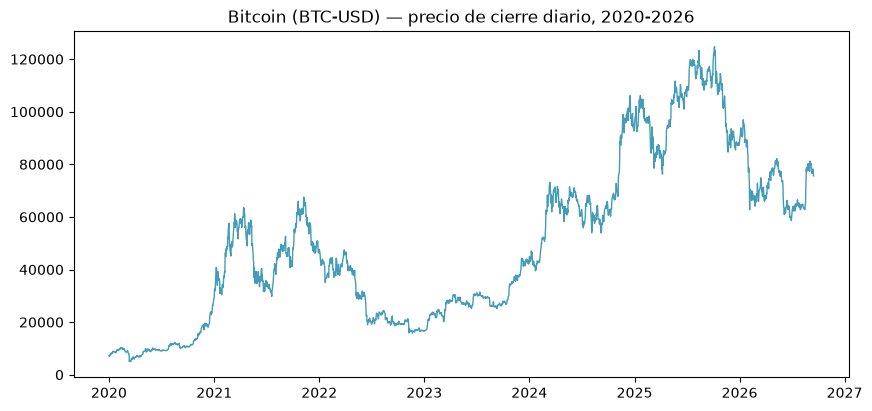

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(btc.index, btc.values, color="#449cb9", linewidth=1)
ax.set_title("Bitcoin (BTC-USD) — precio de cierre diario, 2020-2026")
plt.savefig("bitcoin_precio.png", dpi=110, bbox_inches="tight")
plt.show()

## El Hampel Filter

Un filtro de Hampel detecta atípicos usando una ventana móvil: para cada punto, calcula la mediana y la **MAD** (Median Absolute Deviation, una versión robusta de la desviación típica que no se deja arrastrar por los propios atípicos) de los `k` puntos a cada lado, y marca como atípico cualquier valor a más de `t0` desviaciones MAD de esa mediana local. Es más robusto que un filtro basado en media/desviación típica clásicas precisamente porque la mediana y la MAD no se disparan cuando hay un valor extremo en la ventana.

In [3]:
import numpy as np
import pandas as pd

def hampel_filter(serie, k=7, t0=3):
    """Devuelve (serie_filtrada, indices_atipicos). k = puntos a cada lado de la ventana."""
    x = serie.copy()
    L = 1.4826  # factor que hace que MAD sea comparable a la desviación típica en una normal
    rolling_median = x.rolling(2 * k + 1, center=True).median()
    mad = x.rolling(2 * k + 1, center=True).apply(
        lambda w: np.median(np.abs(w - np.median(w))), raw=True
    )
    threshold = t0 * L * mad
    diff = np.abs(x - rolling_median)
    outlier_idx = diff > threshold
    x_filtered = x.copy()
    x_filtered[outlier_idx] = rolling_median[outlier_idx]
    return x_filtered, outlier_idx

btc_filtrado, atipicos = hampel_filter(btc, k=7, t0=3)
print("nº de atípicos detectados:", int(atipicos.sum()), "de", len(btc), "observaciones")
btc[atipicos].sort_values(ascending=False).head(10)

nº de atípicos detectados: 41 de 2450 observaciones


Date
2025-08-13    123344.062500
2025-07-22    119995.414062
2025-06-09    110294.101562
2025-06-10    110257.234375
2025-06-05    101575.953125
2026-01-05     93882.554688
2026-01-06     93729.031250
2025-12-03     93527.804688
2025-12-01     86321.570312
2025-04-07     79235.335938
Name: btc_usd, dtype: float64

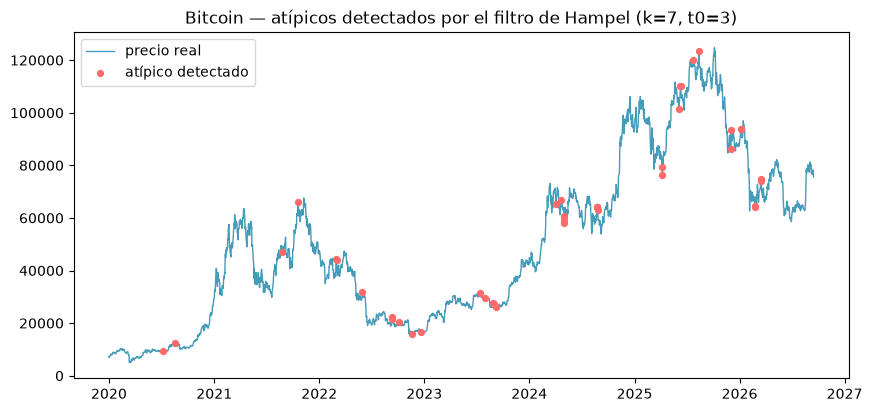

In [4]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(btc.index, btc.values, color="#449cb9", linewidth=1, label="precio real")
ax.scatter(btc.index[atipicos], btc.values[atipicos], color="#ff6b6b", s=18, zorder=5, label="atípico detectado")
ax.legend()
ax.set_title("Bitcoin — atípicos detectados por el filtro de Hampel (k=7, t0=3)")
plt.savefig("bitcoin_hampel.png", dpi=110, bbox_inches="tight")
plt.show()

## Lectura de los atípicos

Es importante no confundir "atípico estadístico" (un movimiento que se sale de la variabilidad local reciente) con "error de datos": en una serie tan volátil como Bitcoin, la mayoría de los puntos marcados por el filtro son movimientos de mercado reales y extremos (caídas o subidas de un solo día muy por encima de lo habitual en esa ventana), no errores de descarga. El Hampel Filter es una herramienta de **detección**, no de "limpieza automática de la verdad" — decidir si un atípico se corrige, se deja o se investiga aparte sigue siendo una decisión humana.

## Sensibilidad al parámetro `t0`

Cuantos menos desviaciones MAD se exijan (`t0` más bajo), más puntos se marcan como atípicos. Se compara con `t0=2` (más sensible) frente al `t0=3` de arriba.

In [5]:
_, atipicos_sensible = hampel_filter(btc, k=7, t0=2)
print("t0=3 (arriba):", int(atipicos.sum()), "atípicos")
print("t0=2 (más sensible):", int(atipicos_sensible.sum()), "atípicos")

t0=3 (arriba): 41 atípicos
t0=2 (más sensible): 112 atípicos


## Cierre

El precio de Bitcoin ya no depende de `coindeskr` (descontinuado): la descarga de Yahoo Finance funciona en vivo y de forma reproducible, verificado con los datos de arriba. El Hampel Filter identifica los movimientos más extremos de la serie sin dejarse arrastrar por ellos —al usar mediana y MAD en vez de media y desviación típica—, la misma técnica que se aplica también en R en esta misma lección con el paquete `pracma`.